In [42]:
from folktables import ACSDataSource, BasicProblem, generate_categories
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import scipy

### 1. Load and Preprocess the data
We are going to work with the [Folktables](https://github.com/socialfoundations/folktables#quick-start-examples) dataset (*you have already worked with it*).

1. As last week, we are still predicting the *Total person's income*  (I've digitized  it in  `target_transform=lambda x: x > 35000`).
2. Today, we are going to see how **Information Leakage** skews the evaluation of models .
4. I kept the filtering method `adult_filter` from the previous lecture


In [2]:
data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=["CA"], download=True)

def adult_filter(data):
    """Mimic the filters in place for Adult data.
    Adult documentation notes: Extraction was done by Barry Becker from
    the 1994 Census database. A set of reasonably clean records was extracted
    using the following conditions:
    ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))
    """
    df = data
    df = df[df['AGEP'] > 16]
    df = df[df['PINCP'] > 100]
    df = df[df['WKHP'] > 0]
    df = df[df['PWGTP'] >= 1]
    df = df[df["RAC1P"] < 3] ## keep only Whites and African-Americans
    return df


ACSIncomeNew = BasicProblem(
    features=[
        'AGEP',
        'COW',
        'SCHL',
        'MAR',
        'CIT',
        'RELP',
        'WKHP',
        'PWGTP',
        'SEX',
        'RAC1P'
    ],
    target='PINCP',
    target_transform=lambda x: x > 35000,    
    group=['SEX', "RAC1P"],
    preprocess=adult_filter,
    postprocess=lambda x: np.nan_to_num(x, -1),
)

In [5]:
definition_df = data_source.get_definitions(download=True)
categories = generate_categories(features=ACSIncomeNew.features, definition_df=definition_df)
features, labels, groups = ACSIncomeNew.df_to_pandas(acs_data, categories=categories, dummies=True)
### groups now contain information about SEX and RAC1P
features.head()

,AGEP,WKHP,PWGTP,"COW_Employee of a private for-profit company or business, or of an individual, for wages, salary, or commissions","COW_Employee of a private not-for-profit, tax-exempt, or charitable organization",COW_Federal government employee,"COW_Local government employee (city, county, etc.)","COW_Self-employed in own incorporated business, professional practice or farm","COW_Self-employed in own not incorporated business, professional practice, or farm",COW_State government employee,...,RELP_Parent-in-law,RELP_Reference person,RELP_Roomer or boarder,RELP_Son-in-law or daughter-in-law,RELP_Stepson or stepdaughter,RELP_Unmarried partner,SEX_Female,SEX_Male,RAC1P_Black or African American alone,RAC1P_White alone
0,21,20.0,52,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,True
1,65,8.0,33,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
2,33,40.0,53,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,18,18.0,106,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4,27,50.0,23,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True


In [6]:
# Drop the "redundant" columns
features = features.drop(["RELP_Unmarried partner",
                          "CIT_U.S. citizen by naturalization",
                          "SEX_Male",
                          "SCHL_1 or more years of college credit, no degree",  
                          "MAR_Divorced", 
                          "RELP_Adopted son or daughter",
                          'COW_Working without pay in family business or farm', 
                        "RAC1P_White alone" ], axis = 1) 

### 2. Model with a proper normalisation (in the training loop)
1. Split Train data into 100 different splits 
2. Train and evaluate model on each of these splits (aka use Cross validation to do so).
    * Use your favourite performance evaluation method.
3. Remember to **normalise data within the fold**.
4. Plot the distribution of performance scores:
    * What is the mean and standard deviation of the distribution?

In [8]:
from tqdm import tqdm # import this to see how fast the training is

In [111]:
# extract features & variables
X = features.values
Y = labels.values.reshape(-1)

accuracy_scores = []
# build 100 different models
for i in tqdm(range(100)):

    X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3, shuffle=True)

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    for f in range(3): 
        mean = np.mean(X_train[:,f])
        std = np.std(X_train[:,f])
        X_train_scaled[:,f] = (X_train_scaled[:,f] - mean)/std
        X_test_scaled[:,f] = (X_test_scaled[:,f] - mean)/std

    # train model - I pick c=0.1 and dont worry too much about picking the optimal hyper parameters
    model = LogisticRegression(C=0.1,fit_intercept=True,max_iter=500).fit(X_train_scaled, Y_train)
    
    # predict on test data
    pred = model.predict(X_test_scaled)

    # calculate accuracy
    accuracy_scores.append(accuracy_score(Y_test,pred))

100%|█████████████████████████████████████████████████████████████| 100/100 [00:54<00:00,  1.82it/s]


In [112]:
print('Model summary statistics (no information leakage)')
print('The average accuracy is {}, with standard deviations of {}'.format(round(np.mean(accuracy_scores),3),round(np.std(accuracy_scores),3)))
print('However, we can get accuracies from {} to {} depending on the data split'.format(round(min(accuracy_scores),3),round(max(accuracy_scores),3)))


Model summary statistics (no information leakage)
The average accuracy is 0.8, with standard deviations of 0.002
However, we can get accuracies from 0.795 to 0.806 depending on the data split


### 3. Model with a WRONG normalisation
1. **Normalise data**
2. Split Train data into 100 different splits 
2. Train and evaluate model on each of these splits (aka use Cross validation to do so).
    * Use your favourite performance evaluation method.
4. Plot the distribution of performance scores:
    * What is the mean and standard deviation of the distribution?

In [110]:
X = features.values
Y = labels.values.reshape(-1)
Xs = X.copy()
# scale features before test/train split
for f in range(3): 
    mean = np.mean(X[:,f])
    std = np.std(X[:,f])
    Xs[:,f] = (X[:,f] - mean)/std

accuracy_info_leakage = []
for i in tqdm(range(100)):

    X_train, X_test, Y_train, Y_test = train_test_split(Xs,Y,test_size=0.3, shuffle=True)

    # train model - I pick c=0.1 and dont worry too much about picking the optimal hyper parameters
    model = LogisticRegression(C=0.1,fit_intercept=True,max_iter=500).fit(X_train, Y_train)
    
    # predict on test data
    pred = model.predict(X_test)

    # calculate accuracy
    accuracy_info_leakage.append(accuracy_score(Y_test,pred))

100%|█████████████████████████████████████████████████████████████| 100/100 [00:45<00:00,  2.20it/s]


In [113]:
print('Model summary statistics (information leakage)')
print('The average accuracy is {}, with standard deviations of {}'.format(round(np.mean(accuracy_info_leakage),3),round(np.std(accuracy_info_leakage),3)))
print('However, we can get accuracies from {} to {} depending on the data split'.format(round(min(accuracy_info_leakage),3),round(max(accuracy_info_leakage),3)))


Model summary statistics (information leakage)
The average accuracy is 0.8, with standard deviations of 0.002
However, we can get accuracies from 0.796 to 0.805 depending on the data split


# figure to compare results

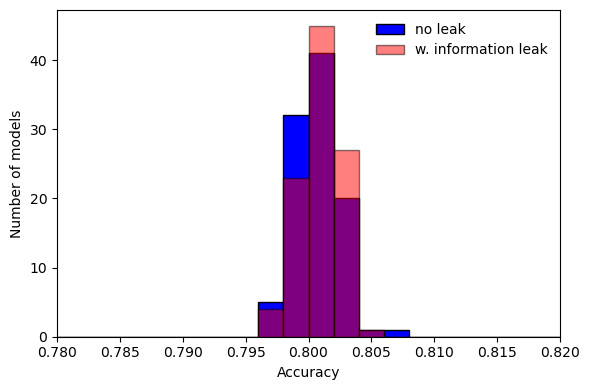

In [109]:
# plot accuracy distribution
plt.figure(figsize=(6,4))
# plot hist accuracy scores using the proper training method
plt.hist(accuracy_scores,bins=np.linspace(0.78,0.82,21),color='blue',edgecolor='black',lw=0.5,label='no leak')
# plot hist accuracy scores when there is an information leak in the system 
plt.hist(accuracy_info_leakage,bins=np.linspace(0.78,0.82,21),color='red',edgecolor='black',lw=0.5,alpha=0.5,label='w. information leak')
plt.xlim(0.78,0.82)
plt.legend(loc=0,frameon=False)
plt.xlabel('Accuracy')
plt.ylabel('Number of models')
plt.tight_layout()
plt.show()